# Aufgaben: Time-Series-Data

### Aufgabe 1 Time-Series-Data

*Identifizieren Sie im UCI Repository (oder von anderen Stellen) einen Datensatz mit temporaler Dynamik. Implementieren Sie ein Neuronales Netz mit dem “naiven Ansatz”, mehrere Instanzen nachrutschend in die Input Schicht zu geben. Evaluieren Sie diesen naiven Ansatz gegen eine Implementierung mittels rekurrenter Layer.*

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math

Realen Datensatz geladen. Größe: 3650 Punkte.
Erste 5 Werte: [[20.7]
 [17.9]
 [18.8]
 [14.6]
 [15.8]]


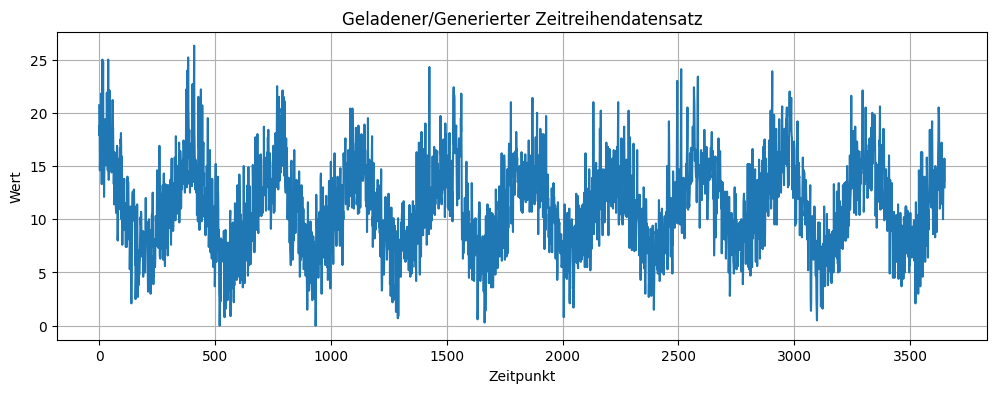

Datensatzgröße: 3650 Punkte


In [ ]:

data_path = "../../../data/daily-minimum-temperatures-in-me.csv" # Pfad zum heruntergeladenen Datensatz

# Laden des Datensatzes
# headern=0 falls die erste Zeile Spaltennamen enthält.
# parse_dates=[0] versucht, die erste Spalte als Datum zu parsen.
# index_col=0 setzt die Datumsspalte als Index.
df_real = pd.read_csv(data_path, header=0, index_col=0, parse_dates=True)

# Nehmen Sie die Werte der Zeitreihe. Stellen Sie sicher, dass es sich um eine univariate Reihe handelt.
# Konvertieren Sie zu Float32 für PyTorch.
raw_data = df_real.values.astype(np.float32)
print(f"Realen Datensatz geladen. Größe: {len(raw_data)} Punkte.")
print("Erste 5 Werte:", raw_data[:5])


# Visualisierung der geladenen/generierten Daten
plt.figure(figsize=(12, 4))
plt.plot(raw_data)
plt.title("Geladener/Generierter Zeitreihendatensatz")
plt.xlabel("Zeitpunkt")
plt.ylabel("Wert")
plt.grid(True)
plt.show()

print(f"Datensatzgröße: {len(raw_data)} Punkte")


In [5]:
# Originaler Code aus der vorherigen Version - KEINE ÄNDERUNG HIER
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(
    raw_data.reshape(-1, 1)
)  # Reshape für MinMaxScaler erwartet 2D-Array

print("Daten skaliert. Beispiel (erste 5):", scaled_data[:5].flatten())


Daten skaliert. Beispiel (erste 5): [0.7870723 0.6806084 0.7148289 0.5551331 0.6007605]


### Sequenzen erstellen (Sliding Window)

Für beide Ansätze (naiv und rekurrent) müssen wir die Zeitreihe in Sequenzen umwandeln. Jede Eingabesequenz besteht aus `window_size` vergangenen Zeitpunkten, und die Ausgabe ist der unmittelbar nächste Zeitpunkt.

In [6]:
def create_sequences(data, window_size):
    """
    Erstellt Zeitreihen-Sequenzen für das Training.
    Input: Zeitreihe [t-window_size, ..., t-1]
    Output: Zeitreihe [t]
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        # x_i ist das Eingabefenster (vergangene Werte)
        x_i = data[i : (i + window_size), 0]
        # y_i ist der vorherzusagende nächste Wert
        y_i = data[i + window_size, 0]
        X.append(x_i)
        y.append(y_i)
    return np.array(X), np.array(y)


window_size = 10  # Die Anzahl der vergangenen Zeitpunkte, die als Eingabe dienen

X_sequences, y_targets = create_sequences(scaled_data, window_size)

print(f"Anzahl der erstellten Sequenzen: {len(X_sequences)}")
print(
    f"Form der Eingabesequenzen (X): {X_sequences.shape}"
)  # (Anzahl Sequenzen, Window Size)
print(f"Form der Zielwerte (y): {y_targets.shape}")  # (Anzahl Sequenzen,)

# Daten in Trainings- und Testsets aufteilen (chronologisch)
# Es ist wichtig, Zeitreihen chronologisch aufzuteilen, um Datenlecks zu vermeiden.
train_size = int(len(X_sequences) * 0.8)
X_train_np, X_test_np = (
    X_sequences[0:train_size],
    X_sequences[train_size : len(X_sequences)],
)
y_train_np, y_test_np = y_targets[0:train_size], y_targets[train_size : len(y_targets)]

print(f"Trainingsdaten X Form: {X_train_np.shape}, y Form: {y_train_np.shape}")
print(f"Testdaten X Form: {X_test_np.shape}, y Form: {y_test_np.shape}")

# Konvertierung zu PyTorch Tensoren
X_train_tensor = torch.from_numpy(X_train_np).float()
y_train_tensor = (
    torch.from_numpy(y_train_np).float().view(-1, 1)
)  # y muss 2D sein für den Loss (Spalte)
X_test_tensor = torch.from_numpy(X_test_np).float()
y_test_tensor = (
    torch.from_numpy(y_test_np).float().view(-1, 1)
)  # y muss 2D sein für den Loss (Spalte)

print(
    f"Trainingsdaten X Tensor Form: {X_train_tensor.shape}, y Tensor Form: {y_train_tensor.shape}"
)


Anzahl der erstellten Sequenzen: 3640
Form der Eingabesequenzen (X): (3640, 10)
Form der Zielwerte (y): (3640,)
Trainingsdaten X Form: (2912, 10), y Form: (2912,)
Testdaten X Form: (728, 10), y Form: (728,)
Trainingsdaten X Tensor Form: torch.Size([2912, 10]), y Tensor Form: torch.Size([2912, 1])


## 3. Naive Ansatz: Feed-Forward Neuronales Netz (FFNN)

Beim 'naiven Ansatz' wird das Eingabefenster (z.B. die letzten 10 Zeitpunkte) einfach zu einem langen Vektor 'flachgewalzt' und als Input in ein traditionelles Feed-Forward Netz gegeben. Das Netz behandelt die aufeinanderfolgenden Zeitpunkte im Fenster als unabhängige Merkmale, ignoriert also explizit die sequenzielle Natur.

In [7]:
class NaiveFFNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(NaiveFFNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = (
            nn.ReLU()
        )  # Aktivierungsfunktion nach der ersten versteckten Schicht
        self.fc2 = nn.Linear(hidden_size, output_size)  # Output Schicht

    def forward(self, x):
        # x kommt hier als (batch_size, window_size) an.
        # Da input_size == window_size, muss hier kein explizites Flattening geschehen.
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out


# Modellparameter
ffnn_input_size = (
    window_size  # Die Größe des Eingabefensters ist der Input für das FFNN
)
ffnn_hidden_size = 50  # Anzahl der Neuronen in der versteckten Schicht
ffnn_output_size = 1  # Wir sagen den nächsten einzelnen Zeitpunkt voraus

ffnn_model = NaiveFFNN(ffnn_input_size, ffnn_hidden_size, ffnn_output_size)

print("Naive FFNN Modellarchitektur:")
print(ffnn_model)


Naive FFNN Modellarchitektur:
NaiveFFNN(
  (fc1): Linear(in_features=10, out_features=50, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=50, out_features=1, bias=True)
)


In [8]:
ffnn_criterion = (
    nn.MSELoss()
)  # Mean Squared Error (MSE) ist eine Standard-Verlustfunktion für Regressionsaufgaben
ffnn_optimizer = optim.Adam(
    ffnn_model.parameters(), lr=0.001
)  # Adam ist ein robuster Optimierer

num_epochs = 100  # Anzahl der Trainings-Epochen (Durchläufe über den gesamten Trainingsdatensatz)
ffnn_train_losses = []  # Liste zur Speicherung des Verlustverlaufs für Visualisierung

print("Starte Training des naiven FFNN...")
for epoch in range(num_epochs):
    ffnn_model.train()  # Setze Modell in Trainingsmodus (wichtig, falls z.B. Dropout verwendet wird)
    ffnn_optimizer.zero_grad()  # Gradienten der vorherigen Iteration zurücksetzen

    outputs = ffnn_model(X_train_tensor)  # Forward-Pass: Vorhersagen generieren
    loss = ffnn_criterion(outputs, y_train_tensor)  # Verlust berechnen
    loss.backward()  # Backward-Pass: Gradienten berechnen
    ffnn_optimizer.step()  # Optimierer-Schritt: Gewichte aktualisieren

    ffnn_train_losses.append(loss.item())  # Verlust für die aktuelle Epoche speichern

    if (epoch + 1) % 10 == 0:  # Ausgabe des Trainingsfortschritts alle 10 Epochen
        print(f"FFNN Epoche [{epoch + 1}/{num_epochs}], Verlust: {loss.item():.6f}")

print("Training des naiven FFNN beendet.")


Starte Training des naiven FFNN...
FFNN Epoche [10/100], Verlust: 0.292367
FFNN Epoche [20/100], Verlust: 0.175351
FFNN Epoche [30/100], Verlust: 0.088216
FFNN Epoche [40/100], Verlust: 0.031416
FFNN Epoche [50/100], Verlust: 0.014225
FFNN Epoche [60/100], Verlust: 0.016241
FFNN Epoche [70/100], Verlust: 0.013939
FFNN Epoche [80/100], Verlust: 0.013249
FFNN Epoche [90/100], Verlust: 0.013066
FFNN Epoche [100/100], Verlust: 0.012747
Training des naiven FFNN beendet.


In [9]:
ffnn_model.eval()  # Setze Modell in Evaluierungsmodus (deaktiviert z.B. Dropout)
with (
    torch.no_grad()
):  # Deaktiviere Gradientenberechnung für die Inferenz, spart Speicher und Zeit
    ffnn_predictions = ffnn_model(X_test_tensor).numpy()  # Vorhersagen auf dem Testset
    ffnn_mse = mean_squared_error(y_test_np, ffnn_predictions)  # Berechne MSE
    ffnn_rmse = math.sqrt(ffnn_mse)  # Berechne RMSE (Root Mean Squared Error)
    print(f"Naive FFNN MSE auf Testset: {ffnn_mse:.6f}")
    print(f"Naive FFNN RMSE auf Testset: {ffnn_rmse:.6f}")


Naive FFNN MSE auf Testset: 0.011272
Naive FFNN RMSE auf Testset: 0.106171


In [10]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size  # Größe der versteckten Zustände
        self.num_layers = num_layers  # Anzahl der übereinander gestapelten LSTM-Layer

        # LSTM-Layer
        # input_size: Dimension der Merkmale eines einzelnen Zeitpunktes (hier 1 für univariate Zeitreihe)
        # hidden_size: Dimension der versteckten und Zellzustände
        # num_layers: Anzahl der LSTM-Layer im Stack
        # batch_first=True: Input-Tensor hat die Form (batch_size, sequence_length, input_size)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # Linearer Layer für die Ausgabe
        # Wandelt den Output des LSTM (letzter versteckter Zustand) in die gewünschte output_size um
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialisiere versteckte Zustände (h0) und Zellzustände (c0) für den LSTM-Layer
        # Diese Zustände werden am Anfang jeder Sequenz auf Null gesetzt.
        # Form: (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward-Pass durch den LSTM-Layer
        # out: Output-Features für jeden Zeit-Schritt der Sequenz (batch_size, sequence_length, hidden_size)
        # (hn, cn): Letzter versteckter Zustand und Zellzustand des gesamten Batches
        out, _ = self.lstm(x, (h0, c0))

        # Für die Vorhersage verwenden wir die Ausgabe des LSTM vom LETZTEN Zeit-Schritt der Sequenz.
        # out[:, -1, :] selektiert den letzten Zeit-Schritt (sequence_length-1) für alle Samples im Batch
        out = self.fc(out[:, -1, :])
        return out


# Modellparameter
lstm_input_size = 1  # Da unsere Zeitreihe univariat ist (ein Feature pro Zeitpunkt)
lstm_hidden_size = 50  # Anzahl der Neuronen im versteckten Zustand des LSTM
lstm_num_layers = 2  # Anzahl der übereinander gestapelten LSTM-Layer
lstm_output_size = 1  # Wir sagen den nächsten einzelnen Zeitpunkt voraus

# Erstelle das LSTM-Modell und verschiebe es auf die CPU (falls keine GPU verfügbar)
lstm_model = LSTMModel(
    lstm_input_size, lstm_hidden_size, lstm_num_layers, lstm_output_size
).to(torch.device("cpu"))

print("LSTM Modellarchitektur:")
print(lstm_model)


LSTM Modellarchitektur:
LSTMModel(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


In [11]:
# Reshape der Daten für LSTM-Input: (batch_size, sequence_length, input_size)
# .view(-1, window_size, lstm_input_size) fügt die 'input_size' Dimension hinzu.
X_train_lstm = X_train_tensor.view(
    X_train_tensor.size(0), window_size, lstm_input_size
).to(torch.device("cpu"))
X_test_lstm = X_test_tensor.view(
    X_test_tensor.size(0), window_size, lstm_input_size
).to(torch.device("cpu"))

print(f"Trainingsdaten X für LSTM Form: {X_train_lstm.shape}")
print(f"Testdaten X für LSTM Form: {X_test_lstm.shape}")


Trainingsdaten X für LSTM Form: torch.Size([2912, 10, 1])
Testdaten X für LSTM Form: torch.Size([728, 10, 1])


### Training des LSTM Models

In [12]:
lstm_criterion = nn.MSELoss()  # MSE als Verlustfunktion für Regression
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)  # Adam als Optimierer

lstm_train_losses = []  # Liste zur Speicherung des Verlustverlaufs

print("Starte Training des LSTM Modells...")
for epoch in range(num_epochs):
    lstm_model.train()  # Setze Modell in Trainingsmodus
    lstm_optimizer.zero_grad()  # Gradienten zurücksetzen

    outputs = lstm_model(X_train_lstm)  # Forward-Pass
    loss = lstm_criterion(outputs, y_train_tensor)  # Verlust berechnen
    loss.backward()  # Backward-Pass
    lstm_optimizer.step()  # Gewichte aktualisieren

    lstm_train_losses.append(loss.item())  # Verlust speichern

    if (epoch + 1) % 10 == 0:
        print(f"LSTM Epoche [{epoch + 1}/{num_epochs}], Verlust: {loss.item():.6f}")

print("Training des LSTM Modells beendet.")


Starte Training des LSTM Modells...
LSTM Epoche [10/100], Verlust: 0.108169
LSTM Epoche [20/100], Verlust: 0.044158
LSTM Epoche [30/100], Verlust: 0.024351
LSTM Epoche [40/100], Verlust: 0.022390
LSTM Epoche [50/100], Verlust: 0.022026
LSTM Epoche [60/100], Verlust: 0.020812
LSTM Epoche [70/100], Verlust: 0.020068
LSTM Epoche [80/100], Verlust: 0.019432
LSTM Epoche [90/100], Verlust: 0.018627
LSTM Epoche [100/100], Verlust: 0.017571
Training des LSTM Modells beendet.


### Evaluierung des LSTM Modells

In [13]:
lstm_model.eval()  # Setze Modell in Evaluierungsmodus
with torch.no_grad():  # Deaktiviere Gradientenberechnung
    outputs = lstm_model(X_test_lstm)
    lstm_predictions = outputs.numpy()  # Konvertiere PyTorch Tensor zu NumPy Array
    lstm_mse = mean_squared_error(y_test_np, lstm_predictions)  # Berechne MSE
    lstm_rmse = math.sqrt(lstm_mse)  # Berechne RMSE
    print(f"LSTM MSE auf Testset: {lstm_mse:.6f}")
    print(f"LSTM RMSE auf Testset: {lstm_rmse:.6f}")


LSTM MSE auf Testset: 0.017123
LSTM RMSE auf Testset: 0.130856


## Vergleich und Visualisierung

Wir vergleichen die Leistung beider Modelle (FFNN und LSTM) anhand des RMSE auf dem Testset. Anschließend visualisieren wir die Vorhersagen beider Modelle gegen die tatsächlichen Werte für einen kleinen Abschnitt der Zeitreihe, um die Unterschiede in der Vorhersagequalität visuell zu erkennen.


--- Modellvergleich ---
Naive FFNN RMSE: 0.106171
LSTM RMSE: 0.130856
Das naive FFNN hat eine bessere oder gleiche Leistung (niedrigeren RMSE) wie das LSTM-Modell.


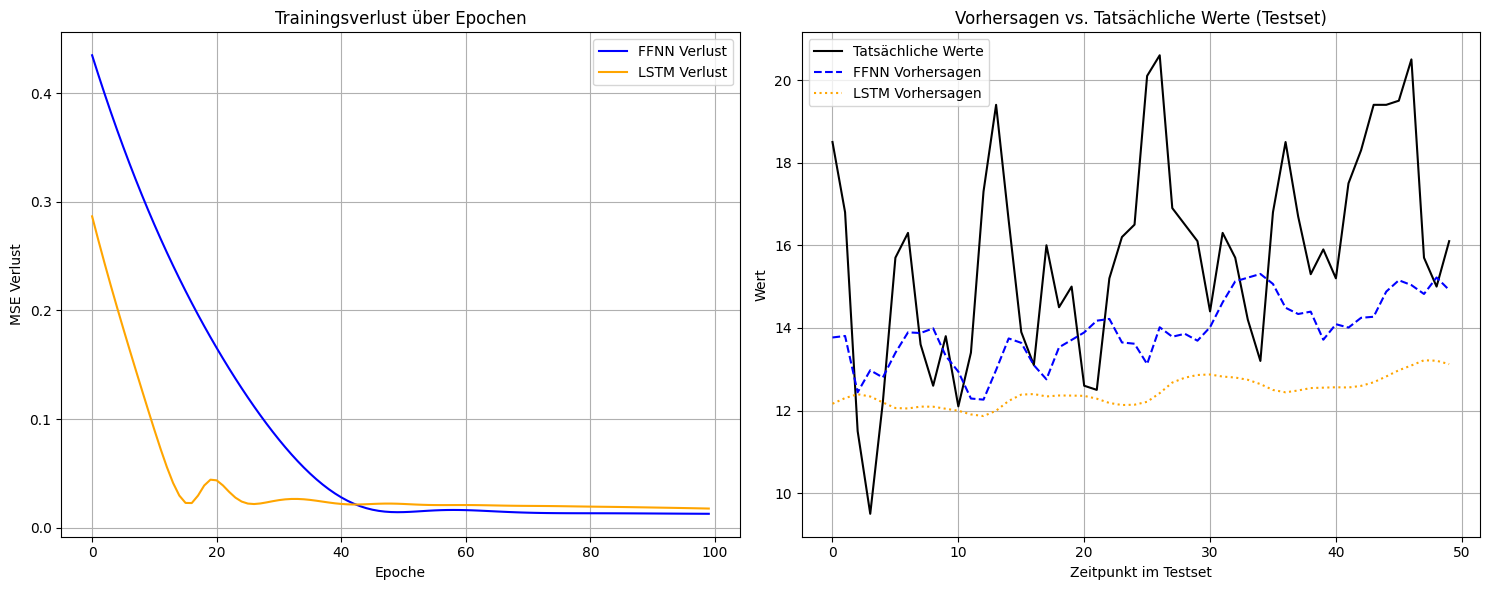

In [14]:
print("\n--- Modellvergleich ---")
print(f"Naive FFNN RMSE: {ffnn_rmse:.6f}")
print(f"LSTM RMSE: {lstm_rmse:.6f}")

if lstm_rmse < ffnn_rmse:
    print(
        "Das LSTM-Modell hat eine bessere Leistung (niedrigeren RMSE) als das naive FFNN."
    )
else:
    print(
        "Das naive FFNN hat eine bessere oder gleiche Leistung (niedrigeren RMSE) wie das LSTM-Modell."
    )


# --- Visualisierung der Vorhersagen ---

plt.figure(figsize=(15, 6))

# Plot 1: Konvergenz der Trainingsverluste beider Modelle
plt.subplot(1, 2, 1)  # 1 Zeile, 2 Spalten, erstes Plot
plt.plot(ffnn_train_losses, label="FFNN Verlust", color="blue")
plt.plot(lstm_train_losses, label="LSTM Verlust", color="orange")
plt.title("Trainingsverlust über Epochen")
plt.xlabel("Epoche")
plt.ylabel("MSE Verlust")
plt.legend()
plt.grid(True)

# Plot 2: Vorhersagen im Vergleich zu den tatsächlichen Werten (Testset)
plt.subplot(1, 2, 2)  # 1 Zeile, 2 Spalten, zweites Plot

# Inverse Skalierung der Daten für eine verständlichere Visualisierung
# Wir zeigen nur einen kleinen Abschnitt des Testsets zur besseren Lesbarkeit
plot_start_idx = 0
plot_end_idx = 50  # Visualisiere die ersten 50 Punkte des Testsets

y_test_original_scale = scaler.inverse_transform(y_test_np.reshape(-1, 1)).flatten()
ffnn_predictions_original_scale = scaler.inverse_transform(ffnn_predictions).flatten()
lstm_predictions_original_scale = scaler.inverse_transform(lstm_predictions).flatten()

time_indices = np.arange(plot_start_idx, plot_end_idx)

plt.plot(
    time_indices,
    y_test_original_scale[plot_start_idx:plot_end_idx],
    label="Tatsächliche Werte",
    color="black",
)
plt.plot(
    time_indices,
    ffnn_predictions_original_scale[plot_start_idx:plot_end_idx],
    label="FFNN Vorhersagen",
    color="blue",
    linestyle="--",
)
plt.plot(
    time_indices,
    lstm_predictions_original_scale[plot_start_idx:plot_end_idx],
    label="LSTM Vorhersagen",
    color="orange",
    linestyle=":",
)

plt.title("Vorhersagen vs. Tatsächliche Werte (Testset)")
plt.xlabel("Zeitpunkt im Testset")
plt.ylabel("Wert")
plt.legend()
plt.grid(True)

plt.tight_layout()  # Passt das Layout an, um Überlappungen zu vermeiden
plt.show()
